<a href="https://colab.research.google.com/github/tsholofelo-mokheleli/Shift-Aware-Explainable-Machine-Learning/blob/main/SAXML-Exploratory%20Data%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Shift-Aware Explainable Machine Learning - Exploratory Data Analysis (EDA)**

### **Import Libraries**

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

import warnings
warnings.filterwarnings('ignore')

### **Load the dataset**

In [56]:
mh_training = pd.read_csv('mh_training_cleaned.csv')
mh_validation = pd.read_csv('mh_validation_cleaned.csv')
mh_testing = pd.read_csv('mh_testing_cleaned.csv')

mh_data = pd.concat([mh_training, mh_validation, mh_testing])
print(mh_data.shape)

(2240, 36)


In [57]:
mh_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2240 entries, 0 to 144
Data columns (total 36 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Diagnosed_mh                                  2240 non-null   int64
 1   Self_employed                                 2240 non-null   int64
 2   Company_size                                  2240 non-null   int64
 3   Employer_tech                                 2240 non-null   int64
 4   Ease_medical_leave                            2240 non-null   int64
 5   Employer_importance_mental                    2240 non-null   int64
 6   Coworker_reaction                             2240 non-null   int64
 7   Sought_treatment                              2240 non-null   int64
 8   Interference_work_effective_treatment         2240 non-null   int64
 9   Interference_work_no_treatment                2240 non-null   int64
 10  Age               

#### **Age distribution**

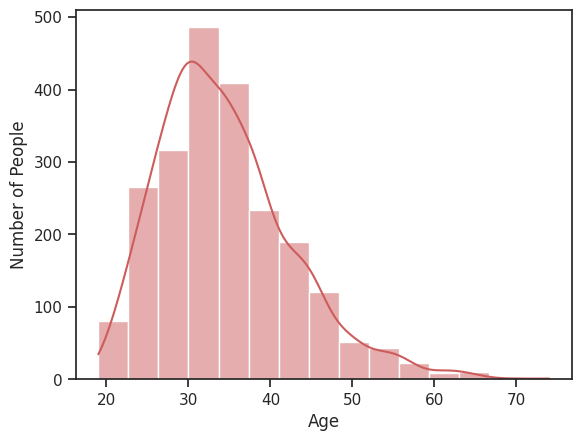

<Figure size 640x480 with 0 Axes>

In [58]:
sns.histplot(data=mh_data, x='Age', kde=True, bins=15, color="indianred")
# plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")
plt.show()

plt.savefig("age_distribution.png")

#### **Gender Distribution**

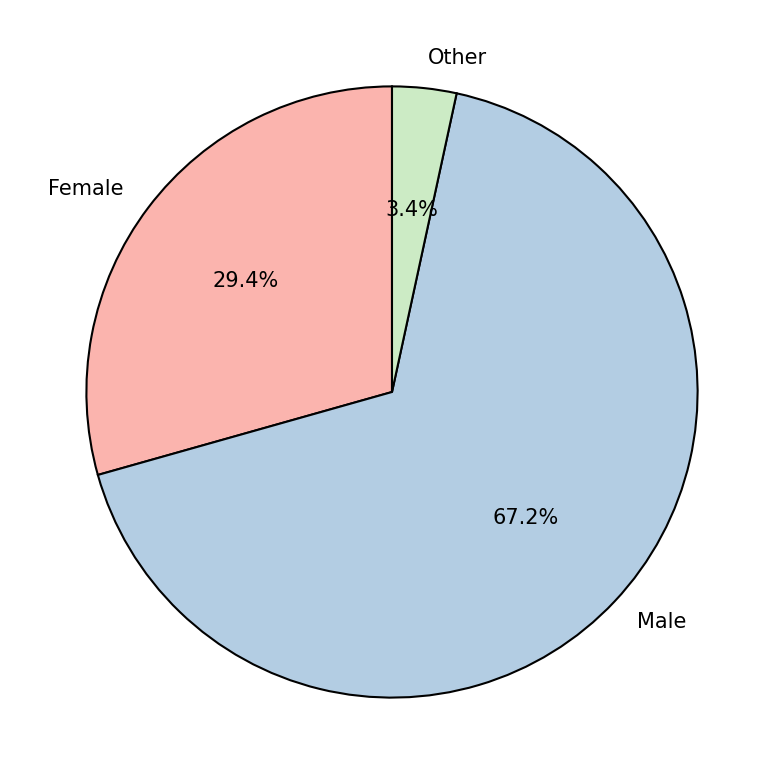

<Figure size 640x480 with 0 Axes>

In [59]:
female_count = (~mh_data['Gender_Male'] & ~mh_data['Gender_Other']).sum()
male_count = mh_data['Gender_Male'].sum()
other_count = mh_data['Gender_Other'].sum()

gender_counts = pd.Series(
    [female_count, male_count, other_count],
    index=['Female', 'Male', 'Other']
)

colors = sns.color_palette("Pastel1", n_colors=3)

plt.figure(figsize=(8, 8))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 15, 'color': 'black'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}
)

plt.tight_layout()
plt.show()

plt.savefig("gender_distribution.png")

#### **Mental health distribution**

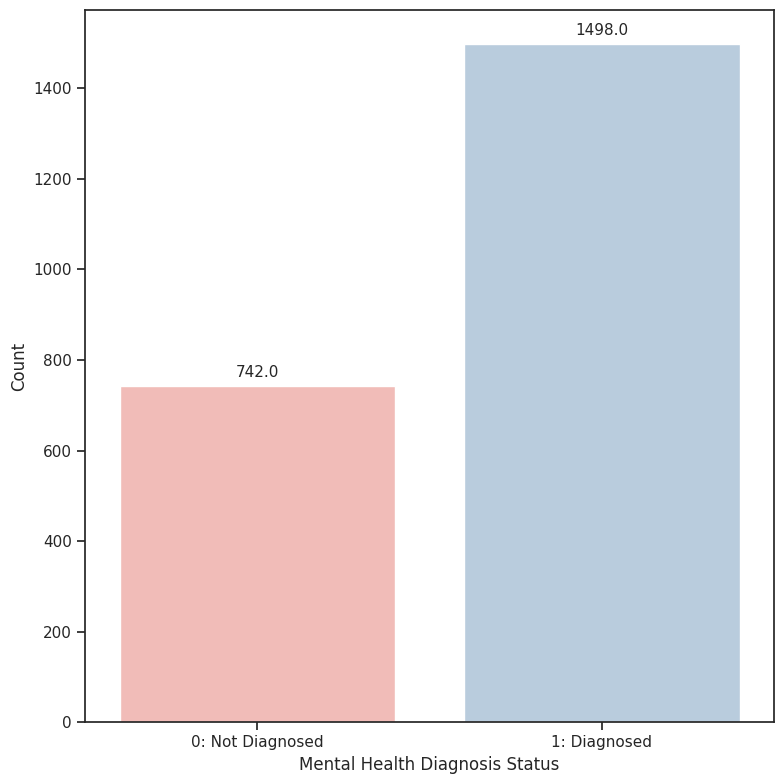

<Figure size 640x480 with 0 Axes>

In [60]:
plt.figure(figsize=(8, 8))

ax = sns.countplot(
    data=mh_data,
    x='Diagnosed_mh',
    palette='Pastel1',
    order=[0, 1]
)

plt.xlabel("Mental Health Diagnosis Status", fontsize=12)
plt.ylabel("Count", fontsize=12)

ax.set_xticklabels(['0: Not Diagnosed', '1: Diagnosed'])

for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11
    )

plt.tight_layout()
plt.show()

plt.savefig("class_distribution.png")

#### **Correlation matrix**

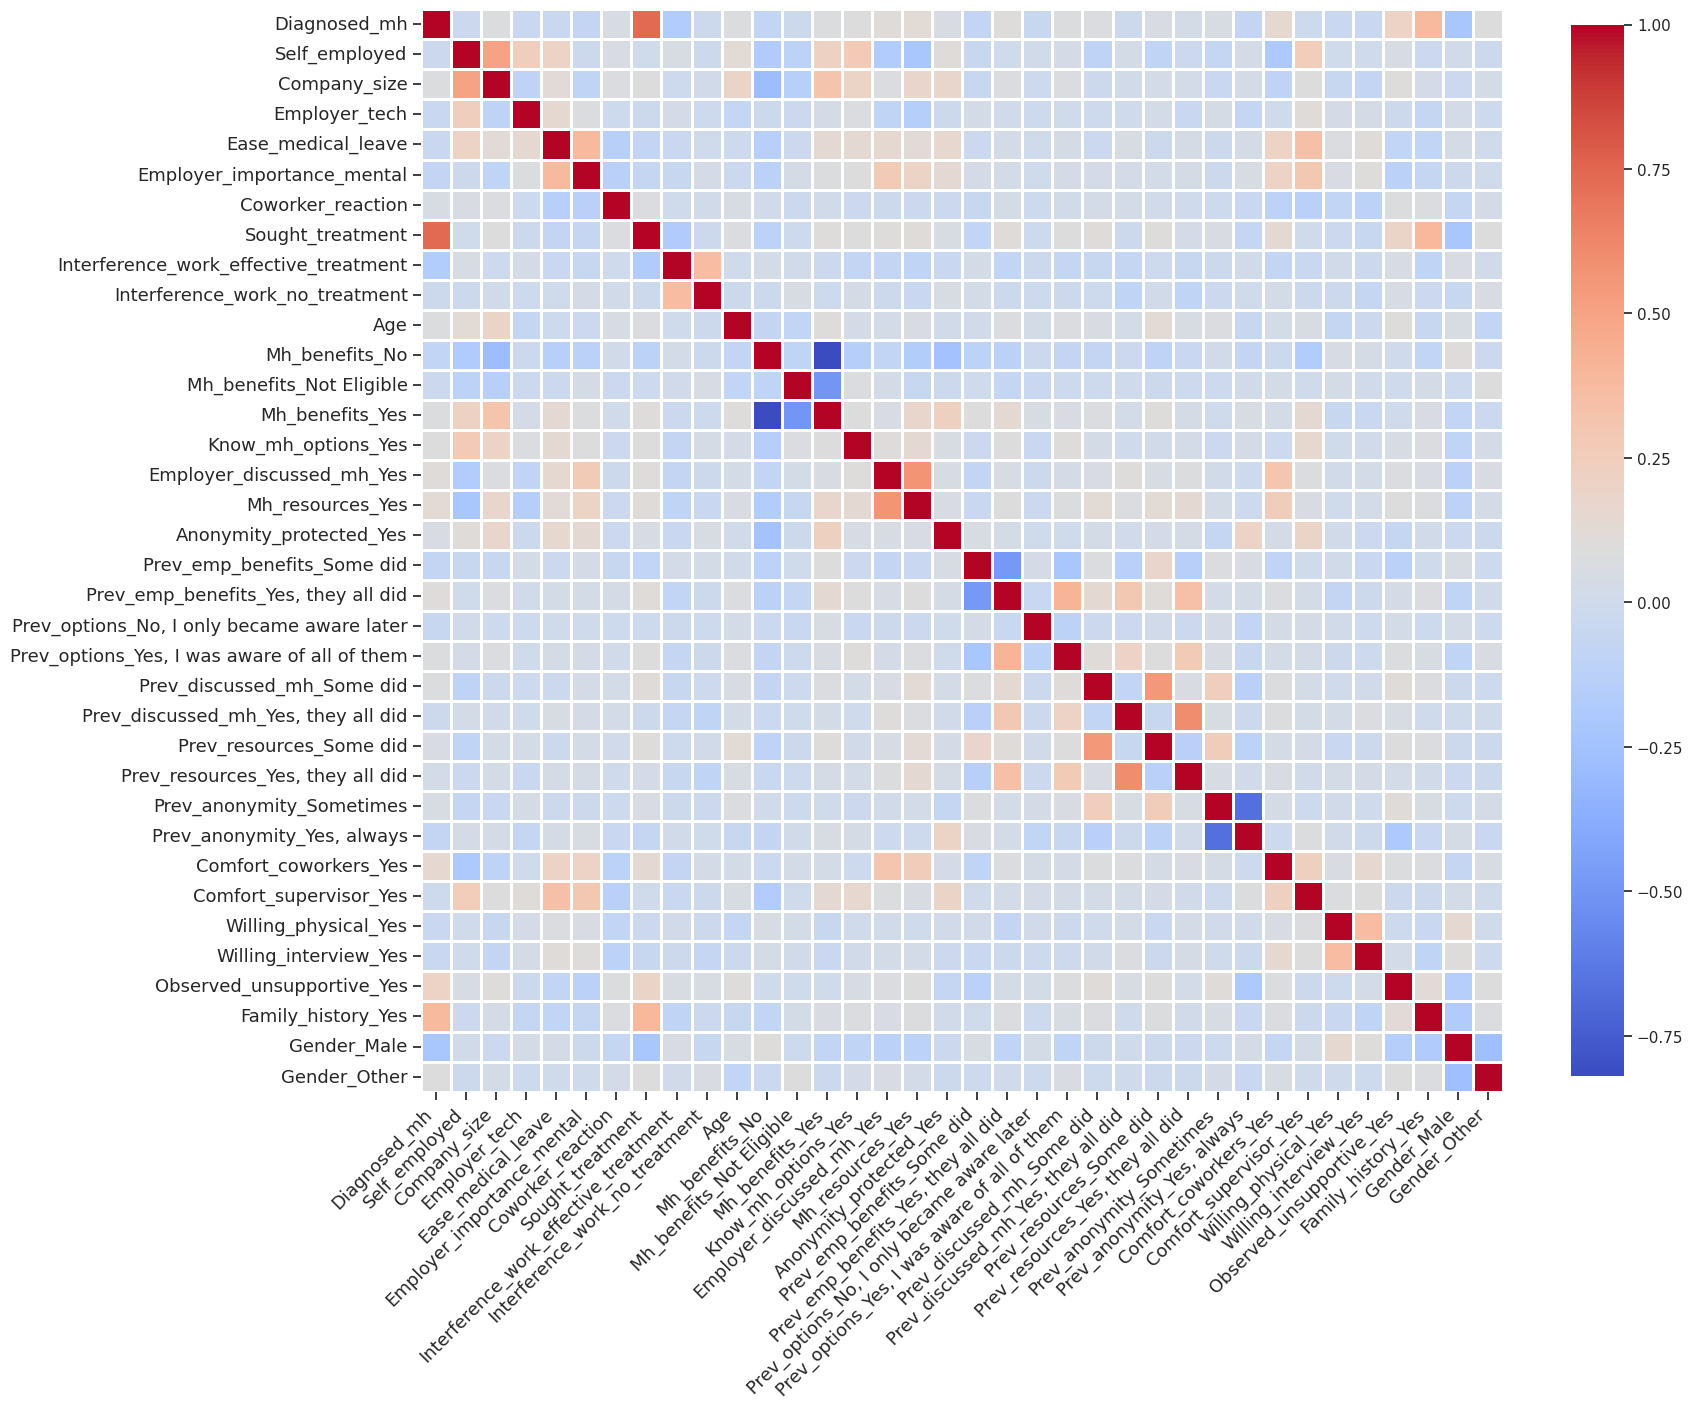

<Figure size 640x480 with 0 Axes>

In [61]:
cmap = "coolwarm"
plt.figure(figsize=(18, 16))

sns.heatmap(
    mh_data.astype(float).corr().round(2),
    linewidths=0.9,
    vmax=1.0,
    square=True,
    linecolor='white',
    annot=False,
    fmt='.2f',
    cmap=cmap,
    cbar_kws={"shrink": .8}
)


plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)

plt.tight_layout()
plt.show()

plt.savefig("correlation_matrix.png")